<a href="https://colab.research.google.com/github/Ado912/cluster_grosir/blob/main/model_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/Durian_Leaf_Diseases_ori.zip

Archive:  /content/drive/MyDrive/Durian_Leaf_Diseases_ori.zip
   creating: Durian_Leaf_Diseases ori/
   creating: Durian_Leaf_Diseases ori/test/
   creating: Durian_Leaf_Diseases ori/test/Leaf_Algal/
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_1.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_102.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_108.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_127.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_129.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_141.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_151.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_155.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_162.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Algal/Leaf_Algal_177.jpg  
  inflating: Durian_Leaf_Diseases ori/test/Leaf_Alga

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.0 MB/s eta 0:00:00


In [ ]:
import os

dataset_path = '/content/Durian_Leaf_Diseases ori' # Path yang benar

for split in ['train', 'val', 'test']:
    split_path = os.path.join(dataset_path, split)
    print(f"\n{split.upper()}:")
    # Memastikan direktori ada sebelum mencoba mengulanginya
    if os.path.exists(split_path):
        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path): # Hanya menghitung subdirektori (kelas)
                jumlah = len(os.listdir(cls_path))
                print(f"  {cls}: {jumlah} gambar")
    else:
        print(f"  Direktori {split_path} tidak ditemukan.")


TRAIN:
  Leaf_Algal: 323 gambar
  Leaf_Blight: 308 gambar
  Leaf_Phomopsis: 287 gambar
  Leaf_Healthy: 338 gambar
  Leaf_Colletotrichum: 280 gambar
  Leaf_Rhizoctonia: 278 gambar

VAL:
  Leaf_Algal: 69 gambar
  Leaf_Blight: 66 gambar
  Leaf_Phomopsis: 61 gambar
  Leaf_Healthy: 72 gambar
  Leaf_Colletotrichum: 60 gambar
  Leaf_Rhizoctonia: 59 gambar

TEST:
  Leaf_Algal: 70 gambar
  Leaf_Blight: 66 gambar
  Leaf_Phomopsis: 63 gambar
  Leaf_Healthy: 74 gambar
  Leaf_Colletotrichum: 60 gambar
  Leaf_Rhizoctonia: 61 gambar


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from ultralytics import YOLO

model=YOLO('yolov8n-cls.pt')

results = model.train(
    data = dataset_path,
    epochs = 50,
    patience = 10,
    batch = 32,
    imgsz = 224,
    project = 'durian_disease',
    name = 'exp1'

)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Durian_Leaf_Diseases ori, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0,

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,442,566 parameters, 0 gradients, 3.3 GFLOPs
train: /content/Durian_Leaf_Diseases ori/train... found 1814 images in 6 classes ✅ 
val: /content/Durian_Leaf_Diseases ori/val... found 387 images in 6 classes ✅ 
test: /content/Durian_Leaf_Diseases ori/test... found 394 images in 6 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1523.8±518.7 MB/s, size: 66.8 KB)
val: Scanning /content/Durian_Leaf_Diseases ori/val... 387 images, 0 corrupt: 100% ━━━━━━━━━━━━ 387/387 108.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 25/25 7.2it/s 3.5s
                   all      0.969          1
Speed: 0.5ms preprocess, 1.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix 

In [ ]:
# Format ONNX (ringan, cocok untuk deployment ke FastAPI nanti)
model.export(format='onnx')

# Atau tetap format .pt (PyTorch native, paling gampang dipakai lagi di Ultralytics)
# File .pt sudah otomatis ada di folder weights, tidak perlu export lagi

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/classify/durian_disease/exp1-2/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 6) (2.8 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 0.4s, saved as '/content/runs/classify/durian_disease/exp1-2/weights/best.onnx' (5.5 MB)

Export complete (0.5s)
Results saved to /content/runs/classify/durian_disease/exp1-2/weights/best.onnx
Predict:         yolo predict task=classify model=/content/runs/classify/durian_disease/exp1-2/weights/best.onnx imgsz=224 
Validate:        yolo val task=classify model=/content/runs/classify/durian_disease/exp1-2/weights/best.onnx imgsz=224 data=/content/Durian_Leaf_Diseases ori  
Visualize:       https://netron.app


'/content/runs/classify/durian_disease/exp1-2/weights/best.onnx'

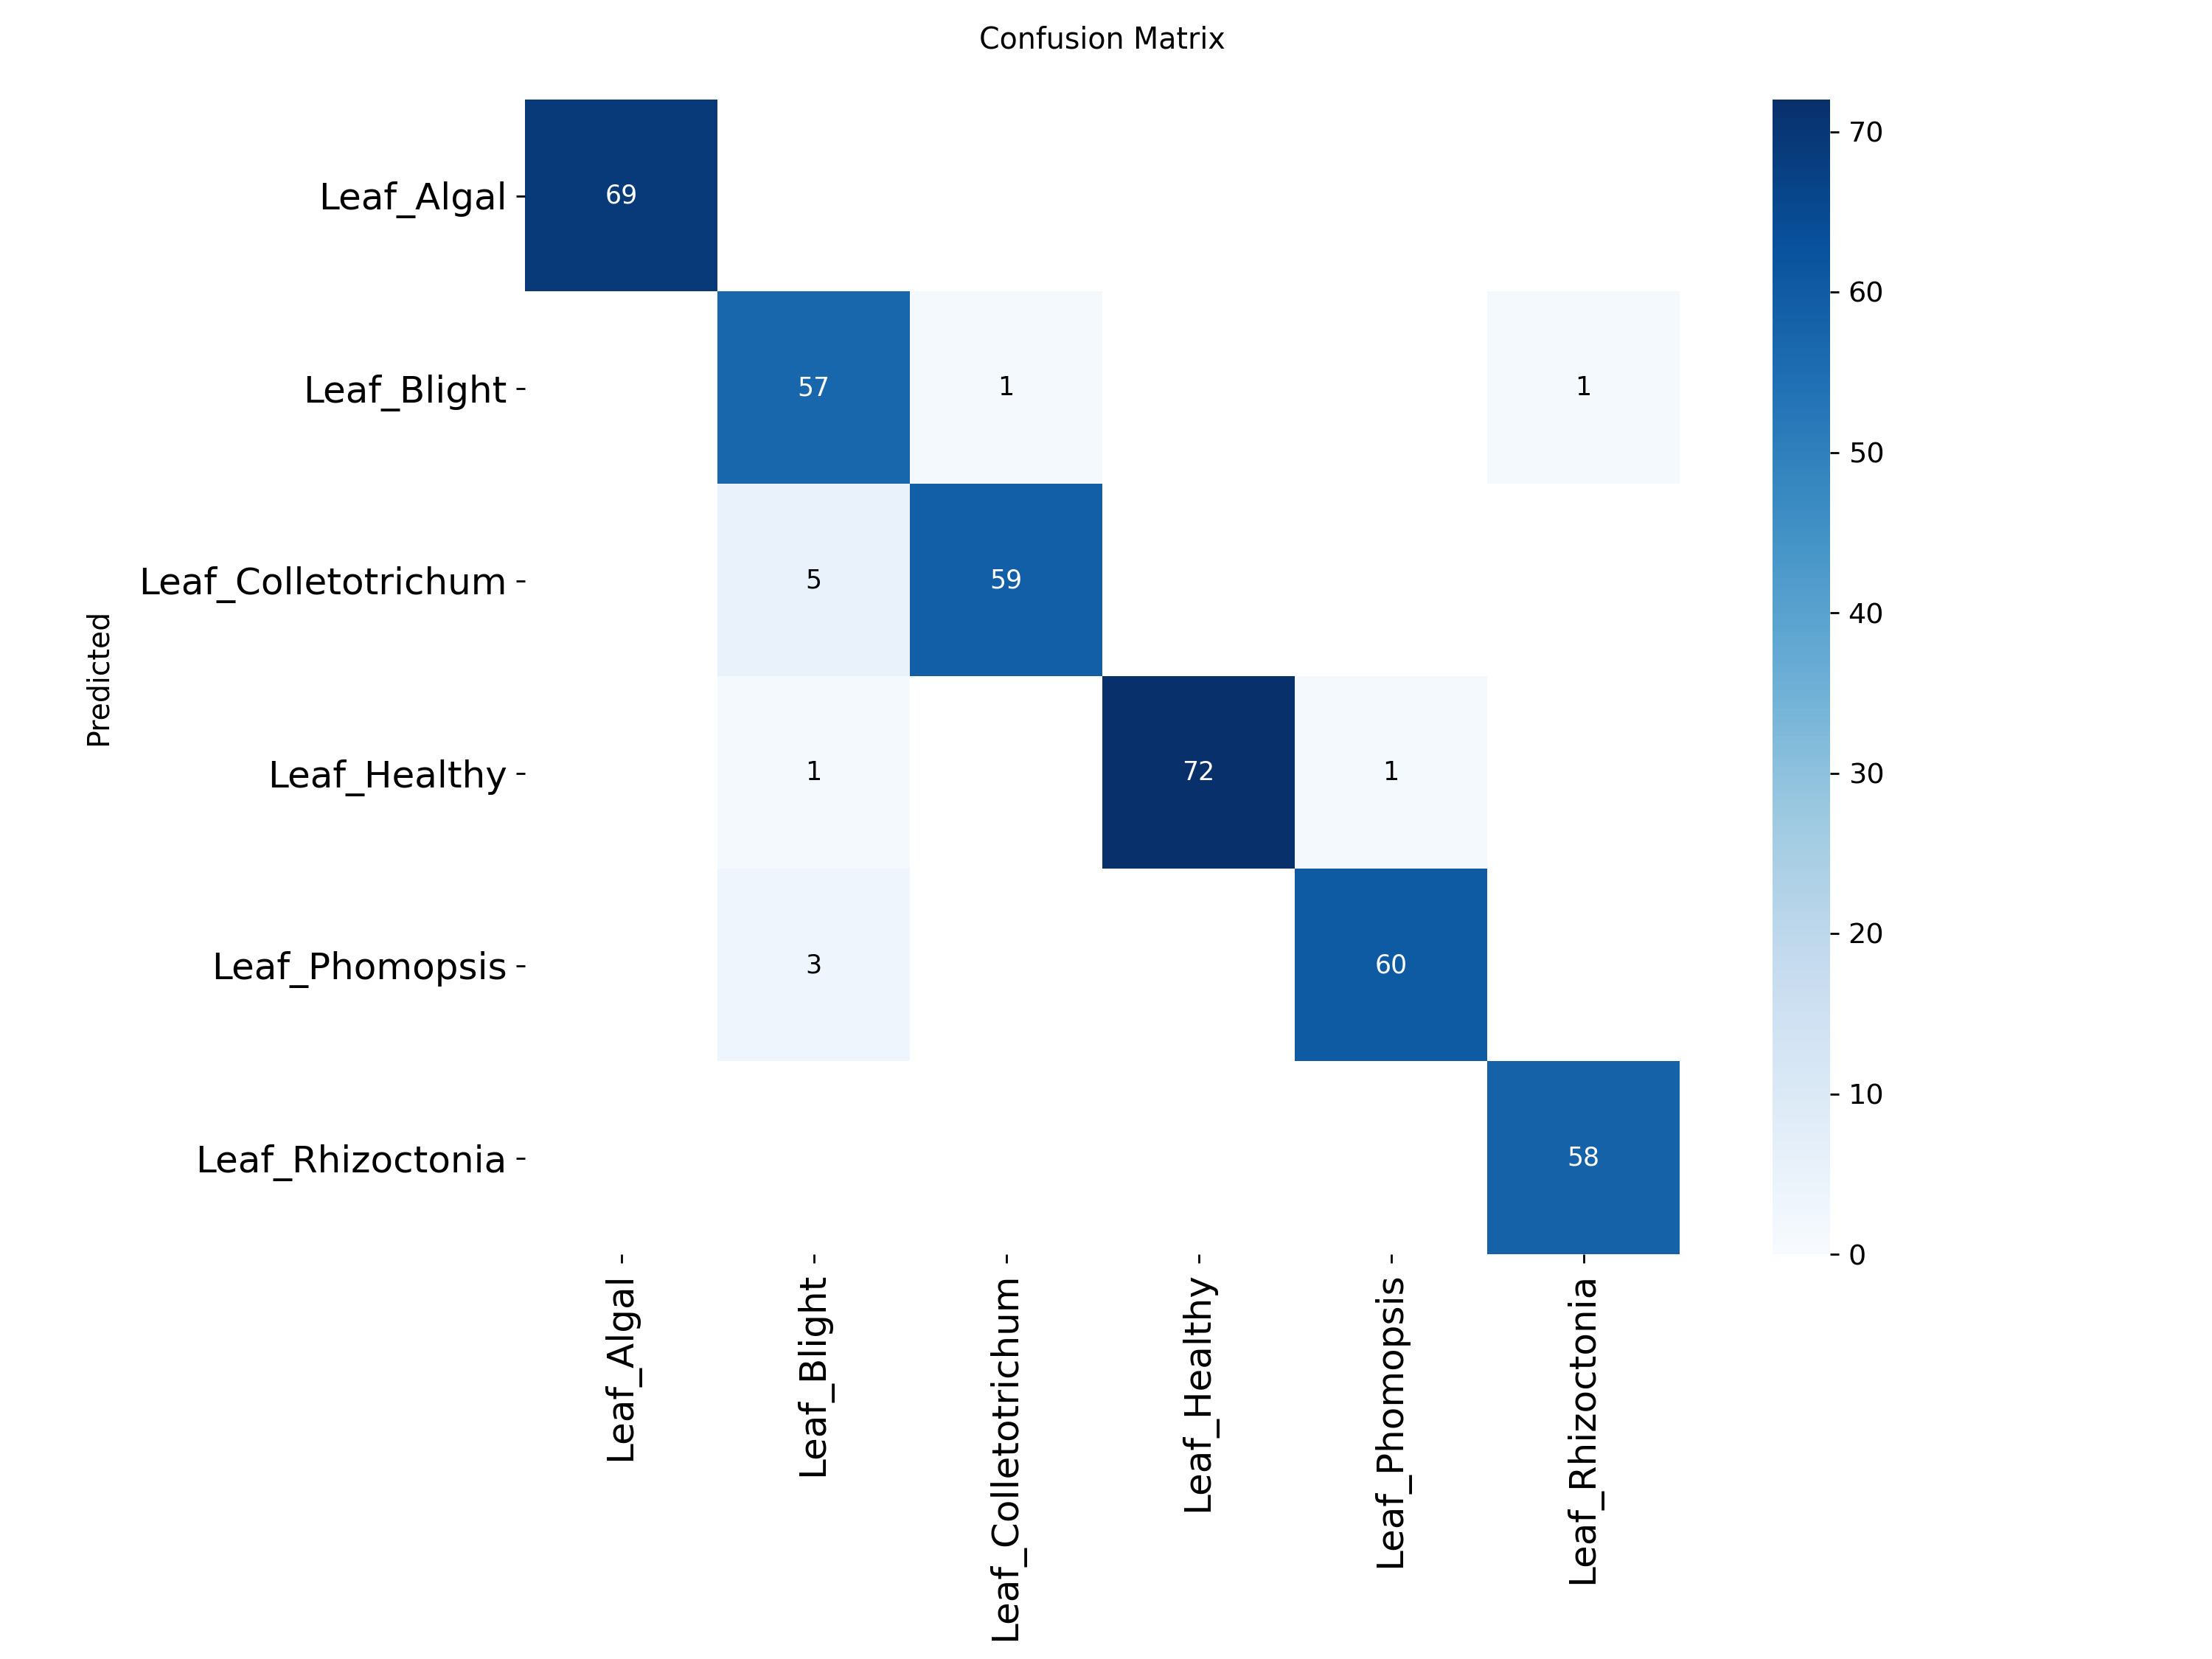

In [ ]:
from IPython.display import Image as IPImage
IPImage('/content/runs/classify/durian_disease/exp1/confusion_matrix.png')

In [ ]:
import numpy as np
from ultralytics import YOLO
import os


model = YOLO('/content/runs/classify/durian_disease/exp1/weights/best.pt')

def get_embedding(img_path):
    results = model.embed(img_path)
    return results[0].cpu().numpy()

# Hitung ulang centroid dari MODEL BARU (yang 96.9%)
centroids = {}
train_dir = '/content/Durian_Leaf_Diseases ori/train'
for kelas in os.listdir(train_dir):
    folder = os.path.join(train_dir, kelas)
    files_list = [os.path.join(folder, f) for f in os.listdir(folder)][:50]  # sample 50 cukup
    embeddings = [get_embedding(p) for p in files_list]
    centroids[kelas] = np.mean(embeddings, axis=0)

def jarak_ke_centroid_terdekat(img_path):
    emb = get_embedding(img_path)
    return min(np.linalg.norm(emb - c) for c in centroids.values())

# Cek jarak untuk gambar DAUN ASLI (dari val)
print("=== Jarak gambar daun asli ===")
val_dir = '/content/Durian_Leaf_Diseases ori/val'
for kelas in os.listdir(val_dir):
    folder = os.path.join(val_dir, kelas)
    sample = os.listdir(folder)[:5]
    for f in sample:
        d = jarak_ke_centroid_terdekat(os.path.join(folder, f))
        print(f"{kelas}/{f}: {d:.2f}")

# Cek jarak untuk gambar BUKAN DAUN (motor, manusia, jeruk yang kamu tes tadi)
print("\n=== Jarak gambar bukan daun ===")
# Corrected paths to existing files based on kernel context
non_daun_files = ['/content/motorbike_0000.jpg', '/content/fruit_0001.jpg']
for f in non_daun_files:
    if os.path.exists(f):
        d = jarak_ke_centroid_terdekat(f)
        print(f"{f}: {d:.2f}")
    else:
        print(f"File not found: {f}. Please upload or provide a correct path.")













































































































































































































































































































=== Jarak gambar daun asli ===

Leaf_Algal/Leaf_Algal_27.jpg: 1.85

Leaf_Algal/Leaf_Algal_134.jpg: 2.17

Leaf_Algal/Leaf_Algal_31.jpg: 2.18

Leaf_Algal/Leaf_Algal_408.jpg: 1.84

Leaf_Algal/Leaf_Algal_19.jpg: 2.62

Leaf_Blight/Leaf_Blight_284.jpg: 2.27

Leaf_Blight/Leaf_Blight_69.jpg: 2.48

Leaf_Blight/Leaf_Blight_427.jpg: 4.08

Leaf_Blight/Leaf_Blight_150.jpg: 2.95

Leaf_Blight/Leaf_Blight_91.jpg: 2.60

Leaf_Phomopsis/Leaf_Phomopsis_329.jpg: 2.26

Leaf_Phomopsis/Leaf_Phomopsis_292.jpg: 2.29

Leaf_Phomopsis/Leaf_Phomopsis_295.jpg: 2.47

Leaf_Phomopsis/Leaf_Phomopsis_255.jpg: 2.45

Leaf_Phomopsis/Leaf_Phomopsis_296.jpg: 2.44

Leaf_Healthy/Leaf_Healthy_415.jpg: 1.80

Leaf_Healthy/Leaf_Healthy_4

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-95kopzgg
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-95kopzgg
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=1f18f87ff30107e284c483ffb05a1e38e0510d1f6e19cc3663e009fb73cdce5c
  Stored in directory: /tmp/pip-ephem-wheel-cache-srl8vc_v/wheels/cb/a8/74/5f32d6cf0407457f0f62737b6da5c14eb86b9cac476fdf630d
Successfully built clip


In [ ]:
import clip
import torch
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model_clip, preprocess = clip.load("ViT-B/32",device = device)

100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 45.0MiB/s]


In [ ]:
def is_daun_durian_clip(img,threshold=0.5):
  image = preprocess(img.open(img_path).convert("RGB")).unsqueeze(0).to(device)
  text= clip.tokenize([
      "foto daun durian",
      "foto manusia",
      "foto sepedamotor",
      "foto buah-buahan",
      "foto bukan daun durian"
  ]).to(device)
  with torch.no_grad():
    logits_per_image,_=model_clip(image,text)
    probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

  prob_daun = probs[0]
  return prob_daun > threshold,prob_daun



silakan upload gambar disini


Saving Leaf_Phomopsis_2.jpg to Leaf_Phomopsis_2.jpg

memproses gambar: Leaf_Phomopsis_2.jpg
Terdeteksi sebagai daun durian: True (probabilitas: 0.784)

image 1/1 /content/Leaf_Phomopsis_2.jpg: 224x224 Leaf_Phomopsis 0.86, Leaf_Algal 0.13, Leaf_Colletotrichum 0.01, Leaf_Blight 0.00, Leaf_Healthy 0.00, 3.2ms
Speed: 2.6ms preprocess, 3.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


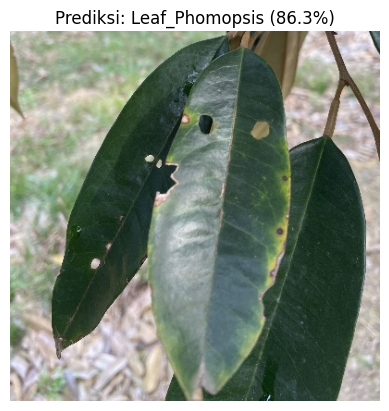

In [ ]:
from google.colab import files
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import clip
import torch

# Setup CLIP (jalankan sekali di awal notebook)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_clip, preprocess = clip.load("ViT-B/32", device=device)

class_names = model.names
print('silakan upload gambar disini')
uploaded = files.upload()

for file_name in uploaded.keys():
    img_path = file_name
    print(f"\nmemproses gambar: {img_path}")

    img = Image.open(img_path).convert("RGB")

    # --- STEP 1: FILTER DULU PAKAI CLIP ---
    def is_daun_durian_clip_v2(pil_img, threshold=0.15):
        image_input = preprocess(pil_img).unsqueeze(0).to(device)

        prompt_positif = [
            "a photo of a durian leaf",
            "a photo of durian leaves on a branch",
            "a photo of a diseased plant leaf with brown spots",
            "a close-up of green leaves"
        ]
        prompt_negatif = [
            "a photo of a person",
            "a photo of a vehicle or motorbike",
            "a photo of fruit",
            "a photo of an object that is not a plant"
        ]

        text = clip.tokenize(prompt_positif + prompt_negatif).to(device)

        with torch.no_grad():
            logits_per_image, _ = model_clip(image_input, text)
            probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

        prob_daun = probs[:len(prompt_positif)].max()  # ambil skor tertinggi dari semua prompt positif
        return prob_daun > threshold, prob_daun

    is_daun, prob = is_daun_durian_clip_v2(img)
    print(f"Terdeteksi sebagai daun durian: {is_daun} (probabilitas: {prob:.3f})")

    # --- STEP 2: BARU KALAU LOLOS FILTER, MASUK KE MODEL YOLO ---
    if is_daun:
        results = model(img_path)
        r = results[0]
        predicted_class = r.names[r.probs.top1]
        confidence = float(r.probs.top1conf) * 100
        title = f'Prediksi: {predicted_class} ({confidence:.1f}%)'
    else:
        title = f'DITOLAK: Gambar bukan daun durian ({prob:.1%} confidence)'

    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
from google.colab import files
files.download('/content/runs/classify/durian_disease/exp1/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model 'best.pt' berhasil disalin ke '/content/drive/MyDrive/durian_disease_model/best.pt'


Sekarang, model `best.pt` Anda sudah tersimpan di Google Drive. Anda bisa memperbarui kode untuk memuat model dari lokasi baru ini jika diperlukan.